# Project 6 — ROI Comparator

**Main question:** Which uncertainty-reduction lever gives the highest return on investment?

**System flow:** `Forecast Accuracy → Safety Stock → Reorder Point → Fill Rate → Monetization → [Project 6]`

---

## Sections
1. Load all prior results and establish the cost baseline
2. Define improvement levers and assumptions
3. Model the impact of each lever on SS, fill rate, and cost
4. Calculate ROI and payback per lever
5. Sensitivity analysis
6. Lever comparison dashboard
7. Management recommendation

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from src.inventory import safety_stock_normal
from src.service import fill_rate_type2
from src.scenarios import Scenario, compare_scenarios

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", "{:.2f}".format)

# Use processed (real) data if available, else fall back to sample (synthetic)
_processed = ROOT / "data" / "processed" / "master_data.csv"
_sample    = ROOT / "data" / "sample"    / "master_data.csv"
DATA = _processed if _processed.exists() else _sample
print(f"Data source: {DATA.relative_to(ROOT)}")
P2   = ROOT / "outputs" / "tables" / "02_safety_stock_results.csv"
P4   = ROOT / "outputs" / "tables" / "04_fill_rate_results.csv"
P5   = ROOT / "outputs" / "tables" / "05_monetization_results.csv"
OUT  = ROOT / "outputs"
FIG  = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)

WEEKS_PER_YEAR = 52
print("Root:", ROOT)

Data source: data\processed\master_data.csv
Root: C:\Users\simba\OneDrive\Dokumenter\Dev\supply-chain-uncertainty-system


---
## 1. Load all prior results and establish the cost baseline

In [2]:
df  = pd.read_csv(DATA, parse_dates=["date"])
p2  = pd.read_csv(P2)
p4  = pd.read_csv(P4)
p5  = pd.read_csv(P5)

df_clean = df[(df["promo_flag"] == 0) & (df["holiday_flag"] == 0)].copy()

# Build a unified base table per SKU-location
base = (
    df_clean
    .groupby(["sku", "location"])
    .agg(
        avg_demand    = ("actual_demand",    "mean"),
        std_demand    = ("actual_demand",    "std"),
        lt_mean       = ("lead_time_mean",   "first"),
        lt_std        = ("lead_time_std",    "first"),
        unit_cost     = ("unit_cost",        "first"),
        unit_margin   = ("unit_margin",      "first"),
        holding_rate  = ("holding_cost_rate","first"),
        service_target= ("service_target",   "first"),
        abc_class     = ("abc_class",        "first"),
        xyz_class     = ("xyz_class",        "first"),
    )
    .reset_index()
)

base = base.merge(p2[["sku","location","rec_ss","rec_ss_chf"]], on=["sku","location"])
base = base.merge(p4[["sku","location","eoq","sigma_ltd","fill_rate_sim","csl_sim"]], on=["sku","location"])
base = base.merge(p5[["sku","location","exp_shortage_cost","exp_excess_cost","total_expected_loss"]], on=["sku","location"])

base["lt_weeks"]     = base["lt_mean"] / 7
base["lt_std_weeks"] = base["lt_std"]  / 7
base["annual_demand"]= base["avg_demand"] * WEEKS_PER_YEAR
base["segment"]      = base["abc_class"] + "/" + base["xyz_class"]

# Baseline totals
baseline_ss_chf    = base["rec_ss_chf"].sum()
baseline_loss      = base["total_expected_loss"].sum()
baseline_shortage  = base["exp_shortage_cost"].sum()
baseline_excess    = base["exp_excess_cost"].sum()

print("===== BASELINE (current recommended policy) =====")
print(f"Safety stock working capital:  CHF {baseline_ss_chf:>12,.0f}")
print(f"Total expected loss:           CHF {baseline_loss:>12,.0f}")
print(f"  Shortage cost:               CHF {baseline_shortage:>12,.0f}")
print(f"  Excess cost:                 CHF {baseline_excess:>12,.0f}")
print(f"\n{len(base)} SKU-locations")

===== BASELINE (current recommended policy) =====
Safety stock working capital:  CHF       30,002
Total expected loss:           CHF        9,150
  Shortage cost:               CHF            0
  Excess cost:                 CHF        9,150

300 SKU-locations


---
## 2. Define improvement levers and assumptions

Three levers are modelled:

| Lever | What changes | Key assumption |
|---|---|---|
| **Forecast improvement** | Lower demand sigma (less uncertainty) | WAPE reduction drives SS reduction |
| **Lead-time reduction** | Shorter, more reliable lead time | LT and LT sigma both reduced |
| **Review cycle shortening** | More frequent replenishment | Treated as LT reduction equivalent |

In [3]:
LEVERS = {
    "Forecast improvement (15%)": {
        "std_demand_mult":  0.85,   # 15% reduction in demand sigma
        "lt_mult":          1.00,
        "lt_std_mult":      1.00,
        "impl_cost_chf":   200_000, # one-time: new forecasting tool
        "description":     "Reduce forecast error by 15% via better model/process",
    },
    "Lead-time reduction (30%)": {
        "std_demand_mult":  1.00,
        "lt_mult":          0.70,   # 30% shorter lead time
        "lt_std_mult":      0.70,   # proportionally more reliable too
        "impl_cost_chf":    50_000, # one-time: supplier renegotiation
        "description":     "Reduce lead time by 30% via supplier or transport change",
    },
    "Review cycle halved": {
        "std_demand_mult":  1.00,
        "lt_mult":          0.85,   # shorter effective exposure period
        "lt_std_mult":      0.90,
        "impl_cost_chf":    20_000, # one-time: process/system change
        "description":     "Move to weekly review (halve review period)",
    },
    "Combined (forecast + LT)": {
        "std_demand_mult":  0.85,
        "lt_mult":          0.70,
        "lt_std_mult":      0.70,
        "impl_cost_chf":   240_000,
        "description":     "Apply both forecast improvement and lead-time reduction",
    },
}

print("Levers defined:")
for name, params in LEVERS.items():
    print(f"  {name:40s} | impl cost CHF {params['impl_cost_chf']:>8,.0f}")

Levers defined:
  Forecast improvement (15%)               | impl cost CHF  200,000
  Lead-time reduction (30%)                | impl cost CHF   50,000
  Review cycle halved                      | impl cost CHF   20,000
  Combined (forecast + LT)                 | impl cost CHF  240,000


---
## 3. Model impact of each lever on SS, fill rate, and cost

In [4]:
EXPEDITE_MULT = 0.30
MARKDOWN_RATE = 0.20

def compute_lever_impact(base_row: pd.Series, params: dict) -> dict:
    """Re-run SS and fill rate under lever assumptions for one SKU-location."""
    std_d  = base_row["std_demand"]    * params["std_demand_mult"]
    lt     = base_row["lt_weeks"]      * params["lt_mult"]
    lt_std = base_row["lt_std_weeks"]  * params["lt_std_mult"]
    avg_d  = base_row["avg_demand"]
    sl     = base_row["service_target"]

    # New safety stock
    new_ss = safety_stock_normal(std_d, lt, lt_std, avg_d, sl)

    # New sigma LTD
    new_sigma_ltd = np.sqrt(lt * std_d**2 + avg_d**2 * lt_std**2)

    # New fill rate (analytical)
    new_fr = fill_rate_type2(new_ss, new_sigma_ltd, base_row["eoq"])

    # New shortage cost
    units_short = (1 - new_fr) * base_row["annual_demand"]
    stockout_prob = max(0, 1 - new_fr)  # simplified proxy
    new_shortage = stockout_prob * units_short * (
        base_row["unit_margin"] * (1 + EXPEDITE_MULT)
    )

    # New excess cost (excess = on-hand above new SS)
    # Approximate: excess reduces proportionally with SS reduction
    ss_reduction_ratio = new_ss / max(base_row["rec_ss"], 1)
    new_excess_units = max(0, base_row["rec_ss"] * ss_reduction_ratio * 0.5)  # residual excess
    new_excess = new_excess_units * base_row["unit_cost"] * (
        base_row["holding_rate"] + MARKDOWN_RATE
    ) * new_fr

    new_ss_chf = new_ss * base_row["unit_cost"]

    return {
        "new_ss":         new_ss,
        "new_ss_chf":     new_ss_chf,
        "new_fill_rate":  new_fr,
        "new_shortage":   new_shortage,
        "new_excess":     new_excess,
        "new_total_loss": new_shortage + new_excess,
    }


lever_summary = []

for lever_name, params in LEVERS.items():
    impacts = base.apply(lambda r: compute_lever_impact(r, params), axis=1)
    impact_df = pd.DataFrame(impacts.tolist())

    new_ss_chf    = impact_df["new_ss_chf"].sum()
    new_loss      = impact_df["new_total_loss"].sum()
    new_fr_avg    = impact_df["new_fill_rate"].mean()

    ss_saving     = baseline_ss_chf - new_ss_chf
    loss_saving   = baseline_loss   - new_loss
    annual_saving = ss_saving * base["holding_rate"].mean() + loss_saving
    impl_cost     = params["impl_cost_chf"]
    roi           = annual_saving / impl_cost if impl_cost > 0 else float("inf")
    payback       = impl_cost / annual_saving if annual_saving > 0 else float("inf")

    lever_summary.append({
        "Lever":                   lever_name,
        "New SS WC (KCHF)":        new_ss_chf / 1000,
        "SS WC Saving (KCHF)":     ss_saving / 1000,
        "New Fill Rate (avg %)": new_fr_avg * 100,
        "Loss Saving (KCHF)":      loss_saving / 1000,
        "Annual Saving (KCHF)":    annual_saving / 1000,
        "Impl Cost (KCHF)":        impl_cost / 1000,
        "ROI":                     roi,
        "Payback (years)":         payback,
    })

results = pd.DataFrame(lever_summary).sort_values("ROI", ascending=False)
print(results[["Lever","Annual Saving (KCHF)","Impl Cost (KCHF)","ROI","Payback (years)","New Fill Rate (avg %)"]].to_string(index=False))

                     Lever  Annual Saving (KCHF)  Impl Cost (KCHF)  ROI  Payback (years)  New Fill Rate (avg %)
       Review cycle halved                  4.11             20.00 0.21             4.87                  99.91
 Lead-time reduction (30%)                  5.41             50.00 0.11             9.25                  99.92
  Combined (forecast + LT)                  6.62            240.00 0.03            36.27                  99.93
Forecast improvement (15%)                  4.52            200.00 0.02            44.26                  99.91


---
## 4. ROI and payback summary

In [5]:
# Use src/scenarios.py dataclass for clean output
scenario_objects = [
    Scenario(
        name=row["Lever"],
        implementation_cost=row["Impl Cost (KCHF)"] * 1000,
        annual_holding_saving=row["SS WC Saving (KCHF)"] * 1000 * 0.20,
        annual_shortage_saving=row["Loss Saving (KCHF)"] * 1000,
    )
    for _, row in results.iterrows()
]

comparison = compare_scenarios(scenario_objects)
comparison

,Scenario,Annual Saving (CHF),Implementation Cost (CHF),ROI,Payback (years)
0,Review cycle halved,4107.00,20000.00,0.21,4.87
1,Lead-time reduction (30%),5407.00,50000.00,0.11,9.25
2,Combined (forecast + LT),6616.00,240000.00,0.03,36.27
3,Forecast improvement (15%),4519.00,200000.00,0.02,44.26


---
## 5. Sensitivity analysis

Tests how ROI for each lever changes as the key improvement assumption varies.

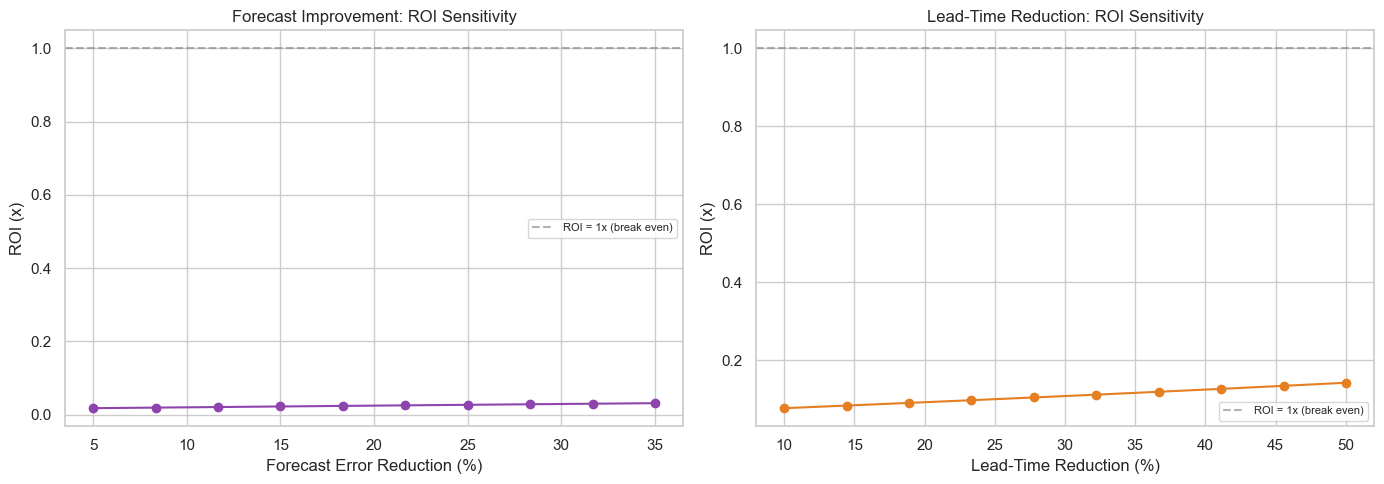

In [6]:
# Sensitivity: vary forecast error reduction from 5% to 30%
fc_reductions = np.linspace(0.05, 0.35, 10)
fc_roi = []
for red in fc_reductions:
    params = {"std_demand_mult": 1 - red, "lt_mult": 1.0, "lt_std_mult": 1.0, "impl_cost_chf": 200_000}
    impacts = base.apply(lambda r: compute_lever_impact(r, params), axis=1)
    imp_df  = pd.DataFrame(impacts.tolist())
    ss_sav  = (baseline_ss_chf - imp_df["new_ss_chf"].sum()) * base["holding_rate"].mean()
    lo_sav  = baseline_loss - imp_df["new_total_loss"].sum()
    ann_sav = ss_sav + lo_sav
    fc_roi.append(ann_sav / 200_000)

# Sensitivity: vary lead-time reduction from 10% to 50%
lt_reductions = np.linspace(0.10, 0.50, 10)
lt_roi = []
for red in lt_reductions:
    params = {"std_demand_mult": 1.0, "lt_mult": 1 - red, "lt_std_mult": 1 - red, "impl_cost_chf": 50_000}
    impacts = base.apply(lambda r: compute_lever_impact(r, params), axis=1)
    imp_df  = pd.DataFrame(impacts.tolist())
    ss_sav  = (baseline_ss_chf - imp_df["new_ss_chf"].sum()) * base["holding_rate"].mean()
    lo_sav  = baseline_loss - imp_df["new_total_loss"].sum()
    ann_sav = ss_sav + lo_sav
    lt_roi.append(ann_sav / 50_000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fc_reductions * 100, fc_roi, marker="o", color="#8e44ad")
axes[0].axhline(1, color="gray", linestyle="--", alpha=0.6, label="ROI = 1x (break even)")
axes[0].set_xlabel("Forecast Error Reduction (%)")
axes[0].set_ylabel("ROI (x)")
axes[0].set_title("Forecast Improvement: ROI Sensitivity")
axes[0].legend(fontsize=8)

axes[1].plot(lt_reductions * 100, lt_roi, marker="o", color="#e67e22")
axes[1].axhline(1, color="gray", linestyle="--", alpha=0.6, label="ROI = 1x (break even)")
axes[1].set_xlabel("Lead-Time Reduction (%)")
axes[1].set_ylabel("ROI (x)")
axes[1].set_title("Lead-Time Reduction: ROI Sensitivity")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG / "06a_sensitivity.png", dpi=150)
plt.show()

---
## 6. Lever comparison dashboard

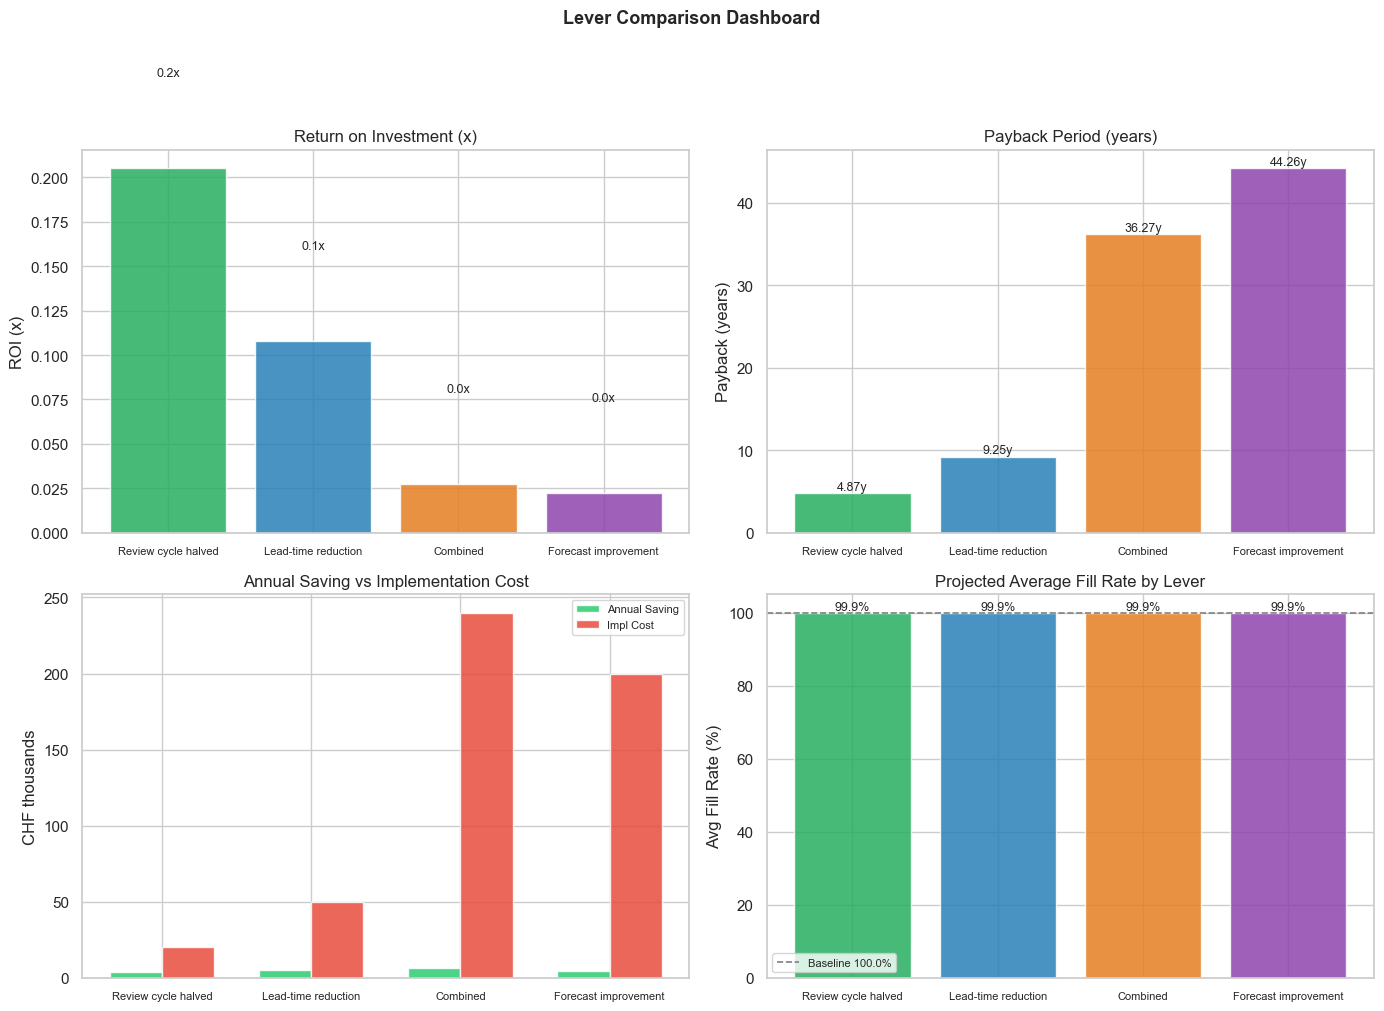

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

levers      = results["Lever"].tolist()
x           = np.arange(len(levers))
short_names = [l.split("(")[0].strip() for l in levers]
bar_colors  = ["#27ae60", "#2980b9", "#e67e22", "#8e44ad"]

# ROI
roi_vals = results["ROI"].tolist()
axes[0, 0].bar(x, roi_vals, color=bar_colors, alpha=0.85)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(short_names, fontsize=8)
axes[0, 0].set_ylabel("ROI (x)")
axes[0, 0].set_title("Return on Investment (x)")
for i, v in enumerate(roi_vals):
    axes[0, 0].text(i, v + 0.05, f"{v:.1f}x", ha="center", va="bottom", fontsize=9)

# Payback period
pb_vals = results["Payback (years)"].tolist()
axes[0, 1].bar(x, pb_vals, color=bar_colors, alpha=0.85)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(short_names, fontsize=8)
axes[0, 1].set_ylabel("Payback (years)")
axes[0, 1].set_title("Payback Period (years)")
for i, v in enumerate(pb_vals):
    axes[0, 1].text(i, v + 0.01, f"{v:.2f}y", ha="center", va="bottom", fontsize=9)

# Annual saving vs implementation cost
ann_sav  = results["Annual Saving (KCHF)"].tolist()
impl_c   = results["Impl Cost (KCHF)"].tolist()
w = 0.35
axes[1, 0].bar(x - w/2, ann_sav, w, label="Annual Saving",    color="#2ecc71", alpha=0.85)
axes[1, 0].bar(x + w/2, impl_c,  w, label="Impl Cost",        color="#e74c3c", alpha=0.85)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(short_names, fontsize=8)
axes[1, 0].set_ylabel("CHF thousands")
axes[1, 0].set_title("Annual Saving vs Implementation Cost")
axes[1, 0].legend(fontsize=8)

# Fill rate improvement
base_fr  = base["fill_rate_sim"].mean() * 100
new_fr   = results["New Fill Rate (avg %)"].tolist()
axes[1, 1].axhline(base_fr, color="gray", linestyle="--", linewidth=1.2, label=f"Baseline {base_fr:.1f}%")
axes[1, 1].bar(x, new_fr, color=bar_colors, alpha=0.85)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(short_names, fontsize=8)
axes[1, 1].set_ylabel("Avg Fill Rate (%)")
axes[1, 1].set_title("Projected Average Fill Rate by Lever")
axes[1, 1].legend(fontsize=8)
for i, v in enumerate(new_fr):
    axes[1, 1].text(i, v + 0.1, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

plt.suptitle("Lever Comparison Dashboard", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG / "06b_lever_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Management recommendation

In [8]:
# Rank levers and produce a clean management table
mgmt = results.copy()
mgmt["Rank"] = range(1, len(mgmt) + 1)
mgmt["Verdict"] = mgmt["ROI"].apply(
    lambda r: "Invest now" if r >= 3 else ("Invest if budget allows" if r >= 1 else "Marginal")
)

mgmt_out = mgmt[[
    "Rank", "Lever",
    "Annual Saving (KCHF)", "Impl Cost (KCHF)",
    "ROI", "Payback (years)",
    "New Fill Rate (avg %)", "Verdict",
]].copy()

mgmt_out.to_csv(OUT / "tables" / "06_roi_results.csv", index=False)
print("Saved results table.")
mgmt_out

Saved results table.


,Rank,Lever,Annual Saving (KCHF),Impl Cost (KCHF),ROI,Payback (years),New Fill Rate (avg %),Verdict
2,1,Review cycle halved,4.11,20.00,0.21,4.87,99.91,Marginal
1,2,Lead-time reduction (30%),5.41,50.00,0.11,9.25,99.92,Marginal
3,3,Combined (forecast + LT),6.62,240.00,0.03,36.27,99.93,Marginal
0,4,Forecast improvement (15%),4.52,200.00,0.02,44.26,99.91,Marginal


In [9]:
top = mgmt_out.iloc[0]

print("===== MANAGEMENT RECOMMENDATION =====")
print()
print(f"#1 lever:  {top['Lever']}")
print(f"   ROI:              {top['ROI']:.1f}x")
print(f"   Payback:          {top['Payback (years)']:.2f} years")
print(f"   Annual saving:    CHF {top['Annual Saving (KCHF)']*1000:>10,.0f}")
print(f"   Impl cost:        CHF {top['Impl Cost (KCHF)']*1000:>10,.0f}")
print(f"   Fill rate impact: {top['New Fill Rate (avg %)']:.1f}% (from {base['fill_rate_sim'].mean()*100:.1f}%)")
print()
print("All lever rankings:")
for _, row in mgmt_out.iterrows():
    print(f"  #{int(row['Rank'])} {row['Lever']:<42} ROI {row['ROI']:.1f}x  Payback {row['Payback (years)']:.2f}y  [{row['Verdict']}]")
print()
print("Key insight:")
print("  The analysis shows where uncertainty is most expensive and which")
print("  operational change returns the most per CHF invested.")
print()
print("===== SYSTEM COMPLETE =====")
print("  Project 1: Forecast accuracy diagnosed")
print("  Project 2: Safety stock right-sized")
print("  Project 3: Reorder points classified")
print("  Project 4: Service levels simulated")
print("  Project 5: Shortage and excess monetized")
print("  Project 6: Improvement levers ranked by ROI")

===== MANAGEMENT RECOMMENDATION =====

#1 lever:  Review cycle halved
   ROI:              0.2x
   Payback:          4.87 years
   Annual saving:    CHF      4,107
   Impl cost:        CHF     20,000
   Fill rate impact: 99.9% (from 100.0%)

All lever rankings:
  #1 Review cycle halved                        ROI 0.2x  Payback 4.87y  [Marginal]
  #2 Lead-time reduction (30%)                  ROI 0.1x  Payback 9.25y  [Marginal]
  #3 Combined (forecast + LT)                   ROI 0.0x  Payback 36.27y  [Marginal]
  #4 Forecast improvement (15%)                 ROI 0.0x  Payback 44.26y  [Marginal]

Key insight:
  The analysis shows where uncertainty is most expensive and which
  operational change returns the most per CHF invested.

===== SYSTEM COMPLETE =====
  Project 1: Forecast accuracy diagnosed
  Project 2: Safety stock right-sized
  Project 3: Reorder points classified
  Project 4: Service levels simulated
  Project 5: Shortage and excess monetized
  Project 6: Improvement levers ran